# 2.1 YouTube Videos Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
from wordcloud import WordCloud
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

## Load and Preprocess the Data

In [2]:
file_paths = {
    "US": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/USvideos.csv",
    "CA": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/CAvideos.csv",
    "GB": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/GBvideos.csv",
    "DE": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/DEvideos.csv",
    "FR": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/FRvideos.csv",
    
}

dfs = []
for country, path in file_paths.items():
    df = pd.read_csv(path)
    df["country"] = country
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202305,coVXf3Q9xBk,18.14.06,عاجل و رسمي : الملف الأمريكي يفوز بشرف تنظيم ك...,KORA LOVERS,1,2018-06-13T12:31:04.000Z,"تنظيم كأس العالم 2026|""كأس العالم 2026""|""المغر...",58758,307,86,485,https://i.ytimg.com/vi/coVXf3Q9xBk/default.jpg,False,False,False,المغرب تخسر تنظيم مونديال كاس العالم 2026 لصال...,FR
202306,_umkjOQJvtw,18.14.06,شاهد ملخص البرلمان اليوم بحضور اخنوش الدي يعطي...,Jadal جدل,25,2018-06-12T17:51:24.000Z,"الباكالوريا في المغرب|""صحاب الباك""|""صحاب الباك...",264639,2011,999,1397,https://i.ytimg.com/vi/_umkjOQJvtw/default.jpg,False,False,False,ملخص ابرز ما حصل في جلسة البرلمان يوم 12/06/20...,FR
202307,nt25ec7nzIM,18.14.06,UN ANIME EXPLOSIF A VOIR ABSOLUMENT !,RushManga,22,2018-06-13T11:50:18.000Z,"RushManga|""rush manga""|""anime a voir""|""UN ANIM...",47510,4601,61,615,https://i.ytimg.com/vi/nt25ec7nzIM/default.jpg,False,False,False,•● Yozakura Quartet ~Hana no Uta~ ●•☆ S'abonne...,FR
202308,NlxE_QQMRzg,18.14.06,"Նռան հատիկ, Սերիա 192 / Pomegranate seed / Nra...",PanArmenian TV,1,2018-06-13T18:30:00.000Z,"Նռան հատիկ|""Սերիա 192""|""Pomegranate seed""|""Nra...",78117,244,74,46,https://i.ytimg.com/vi/NlxE_QQMRzg/default.jpg,False,False,False,Follow Armenia TV on social platforms:Instagra...,FR


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202310 entries, 0 to 202309
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                202310 non-null  object
 1   trending_date           202310 non-null  object
 2   title                   202310 non-null  object
 3   channel_title           202310 non-null  object
 4   category_id             202310 non-null  int64 
 5   publish_time            202310 non-null  object
 6   tags                    202310 non-null  object
 7   views                   202310 non-null  int64 
 8   likes                   202310 non-null  int64 
 9   dislikes                202310 non-null  int64 
 10  comment_count           202310 non-null  int64 
 11  thumbnail_link          202310 non-null  object
 12  comments_disabled       202310 non-null  bool  
 13  ratings_disabled        202310 non-null  bool  
 14  video_error_or_removed  202310 non-n

In [4]:
df.isna().sum()

video_id                     0
trending_date                0
title                        0
channel_title                0
category_id                  0
publish_time                 0
tags                         0
views                        0
likes                        0
dislikes                     0
comment_count                0
thumbnail_link               0
comments_disabled            0
ratings_disabled             0
video_error_or_removed       0
description               6942
country                      0
dtype: int64

In [5]:
df.nunique()

video_id                   79408
trending_date                205
title                      79736
channel_title              16659
category_id                   18
publish_time               72941
tags                       66247
views                     153770
likes                      63446
dislikes                   14883
comment_count              22710
thumbnail_link             79389
comments_disabled              2
ratings_disabled               2
video_error_or_removed         2
description                69866
country                        5
dtype: int64

In [6]:
import unicodedata
import re

def normalize_title(title):
    title = str(title).strip().lower()
    title = unicodedata.normalize('NFKD', title)
    title = re.sub(r'[^\w\s]', ' ', title)
    title = re.sub(r'\s+', ' ', title)
    return title

In [7]:
df['title'] = df['title'].apply(normalize_title)

In [8]:
df[['title', 'video_id']].nunique()

title       79495
video_id    79408
dtype: int64

In [9]:
title_counts = df.groupby('video_id')['title'].nunique()
print((title_counts > 1).sum())
print(df[df['video_id'].isin(title_counts[title_counts > 1].index)][['video_id', 'title']].sort_values('video_id'))

598
           video_id                                              title
136997  --I0aj8MUdU  e diela shqiptare ka nje mesazh per ty pjesa 1...
177883  --I0aj8MUdU  e diela shqiptare ka nje mesazh per ty pjesa 1...
137298  --I0aj8MUdU  e diela shqiptare ka nje mesazh per ty 04 shku...
170293  -IBN1TQpQTU                  le pe re noe l m offre un cheval 
170049  -IBN1TQpQTU           saphir le pe re noe l m offre un cheval 
...             ...                                                ...
4843    zslYmBRhdOM     it s ok to feel sad at christmas vlogmas day 7
5753    zslYmBRhdOM     it s ok to feel sad at christmas vlogmas day 7
168480  zuUvww-qY4I           un truc de fou avec soprano ne o the one
167995  zuUvww-qY4I  je monte sur sce ne avec soprano devant 20 000...
168203  zuUvww-qY4I           un truc de fou avec soprano ne o the one

[4097 rows x 2 columns]


In [10]:
dup_thumbs = df.groupby('thumbnail_link')['video_id'].nunique()
shared_thumbs = dup_thumbs[dup_thumbs > 1]
print(f"Number of shared thumbnails: {len(shared_thumbs)}")

Number of shared thumbnails: 35


In [11]:
l = []
for link in shared_thumbs.index:
    print(f"\nThumbnail: {link}")
    print(df[df['thumbnail_link'] == link]['title'].unique())
    l.append(df[df['thumbnail_link'] == link]['title'].unique())


Thumbnail: https://i.ytimg.com/vi/-V1Oo7srGf0/default.jpg
['your date is here horror short' 'deleted video']

Thumbnail: https://i.ytimg.com/vi/0YVbVXOjJv4/default.jpg
['2018 kia stinger steven tyler big game ad feel something again'
 'deleted video']

Thumbnail: https://i.ytimg.com/vi/5bniROfg5R0/default.jpg
['neue kino trailer 2018 german deutsch kw 4' 'deleted video']

Thumbnail: https://i.ytimg.com/vi/5zGHUwkMaoo/default.jpg
[' سوار_شعيب هل الماضي جميل ' 'deleted video']

Thumbnail: https://i.ytimg.com/vi/AUSspdHxNt4/default.jpg
['pole mique the voice les propos d isabelle morini bosc sur mennel et son chant en arabe '
 'deleted video']

Thumbnail: https://i.ytimg.com/vi/CBF-sjryWEE/default.jpg
['твое имя треи лер rus 2 ' 'deleted video']

Thumbnail: https://i.ytimg.com/vi/DTtDNEG09QM/default.jpg
['rome o elvis le motel nappeux ft grems' 'deleted video'
 'rome o elvis le motel nappeux ft grems ft grems']

Thumbnail: https://i.ytimg.com/vi/F4Xwm-yL3Js/default.jpg
['be be panda a 6 

In [12]:
(df['title'] == 'deleted video').sum()

np.int64(36)

In [13]:
ddf = df[df['title'] == 'deleted video']
df = df[df['title']!= 'deleted video']

In [14]:
df.nunique()

video_id                   79384
trending_date                205
title                      79494
channel_title              16659
category_id                   18
publish_time               72941
tags                       66247
views                     153770
likes                      63446
dislikes                   14883
comment_count              22710
thumbnail_link             79389
comments_disabled              2
ratings_disabled               2
video_error_or_removed         2
description                69866
country                        5
dtype: int64

In [15]:
dups = df['video_id'].value_counts()
print("Video IDs with duplicates:", (dups > 1).sum())

Video IDs with duplicates: 31755


In [16]:
thumbs_per_video = df.groupby('video_id')['thumbnail_link'].nunique()

multi_thumb_videos = thumbs_per_video[thumbs_per_video > 1]

print(f"Number of video_ids with multiple thumbnails: {len(multi_thumb_videos)}")

Number of video_ids with multiple thumbnails: 5


In [17]:
df[df['video_id'].isin(multi_thumb_videos.index)].sort_values('video_id').head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
51193,5ajEkB3zzuk,18.04.01,watch live 2018 new year celebrations around t...,NBC News,25,2018-01-01T09:25:16.000Z,"nbc news|""breaking news""|""us news""|""world news...",2735264,15128,1764,0,https://i.ytimg.com/vi/5ajEkB3zzuk/default.jpg,True,False,False,"From Sydney to New York City, count down to 20...",CA
50961,5ajEkB3zzuk,18.03.01,watch live 2018 new year celebrations around t...,NBC News,25,2018-01-01T09:25:16.000Z,"nbc news|""breaking news""|""us news""|""world news...",2718035,15097,1746,0,https://i.ytimg.com/vi/5ajEkB3zzuk/default.jpg,True,False,False,"From Sydney to New York City, count down to 20...",CA
50744,5ajEkB3zzuk,18.02.01,watch live 2018 new year celebrations around t...,NBC News,25,2018-01-01T09:25:16.000Z,"nbc news|""breaking news""|""us news""|""world news...",2681912,14958,1697,0,https://i.ytimg.com/vi/5ajEkB3zzuk/default.jpg,True,False,False,"From Sydney to New York City, count down to 20...",CA
50541,5ajEkB3zzuk,18.01.01,watch live 2018 new year celebrations around t...,NBC News,25,2017-12-31T12:24:52.000Z,"nbc news|""breaking news""|""us news""|""world news...",2286528,13707,1336,0,https://i.ytimg.com/vi/5ajEkB3zzuk/default_liv...,True,False,False,"From Sydney to New York City, count down to 20...",CA
171336,5ajEkB3zzuk,18.01.01,watch live 2018 new year celebrations around t...,NBC News,25,2017-12-31T12:24:52.000Z,"nbc news""|""breaking news""|""us news""|""world new...",2286528,13707,1336,0,https://i.ytimg.com/vi/5ajEkB3zzuk/default_liv...,True,False,False,"From Sydney to New York City, count down to 20...",FR


In [18]:
main_titles = df.groupby('video_id')['title'].agg(lambda x: x.mode().iloc[0])
df['title'] = df['video_id'].map(main_titles)

In [19]:
df.nunique()

video_id                   79384
trending_date                205
title                      78890
channel_title              16659
category_id                   18
publish_time               72941
tags                       66247
views                     153770
likes                      63446
dislikes                   14883
comment_count              22710
thumbnail_link             79389
comments_disabled              2
ratings_disabled               2
video_error_or_removed         2
description                69866
country                        5
dtype: int64

In [20]:
title_counts = df.groupby('title')['video_id'].nunique()
shared_titles = title_counts[title_counts > 1]
print(f"Number of titles used by multiple video_ids: {len(shared_titles)}")

Number of titles used by multiple video_ids: 349


In [21]:
for title in shared_titles.index[:5]:
    vids = df[df['title'] == title]['video_id'].unique()
    print(f"\n🔹 Title: {title}")
    print(f"Video IDs: {vids}")


🔹 Title:  
Video IDs: ['r46PllA7gZE' 'ozBlmGzRizM' 'nKuWFx7lch4' 'woAyL_zyQFo' '-lovPHT6K6o']

🔹 Title:  best off decoupage balles anti stress 12 
Video IDs: ['lhUG9Lfl2rU' 'BHyt6TcPAM0']

🔹 Title:  compilation iceberg slime 7 
Video IDs: ['4YA0NX8JzoQ' 'Af5VPetariw']

🔹 Title:  l at taque de sylvie vartan a e branle laeti cia hally day et ses proches
Video IDs: ['NWpbz6WHt0Q' '8j-kZaBmxTc']

🔹 Title:  live momo va draguer des meufs ce soir gta 5 rp
Video IDs: ['XZSrtauq5Sc' 'YLUHAq_CO_E']


In [22]:
import json
category_files = {
    "US": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/US_category_id.json",
    "CA": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/CA_category_id.json",
    "GB": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/GB_category_id.json",
    "DE": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/DE_category_id.json",
    "FR": "/home/alizgiz/Data-Science/Courses/sbu-ds-2025/Assignments/2/Data/FR_category_id.json",
}

country_category_maps = {}
for country, file_path in category_files.items():
    with open(file_path, 'r') as f:
        data = json.load(f)
        mapping = {int(item['id']): item['snippet']['title'] for item in data['items']}
        country_category_maps[country] = mapping

def get_category_name(row):
    return country_category_maps[row['country']].get(row['category_id'], None)

df['category_name'] = df.apply(get_category_name, axis=1)

In [23]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format='%y.%d.%m')
df["publish_time"] = pd.to_datetime(df["publish_time"])
df["publish_date"] = df["publish_time"].dt.date
df["publish_hour"] = df["publish_time"].dt.hour
df["publish_day"] = df["publish_time"].dt.day_name()
df['trending_month'] = df['publish_time'].dt.month_name()
df["trending_day"] = df["trending_date"].dt.day_name()
df['trending_month'] = df['trending_date'].dt.month_name()

In [24]:
df["dislike_ratio"] = df["dislikes"] / (df["likes"] + df["dislikes"] + 1e-5)

df["title_length"] = df["title"].apply(len)

df["title_sentiment"] = df["title"].apply(lambda x: TextBlob(x).sentiment.polarity)

In [25]:
df[['views', 'likes', 'dislikes', 'comment_count', 'dislike_ratio', 'title_length', 'title_sentiment']].describe()

,views,likes,dislikes,comment_count,dislike_ratio,title_length,title_sentiment
count,2.022740e+05,2.022740e+05,2.022740e+05,2.022740e+05,202274.000000,202274.000000,202274.000000
mean,2.053475e+06,5.683008e+04,3.068083e+03,6.178461e+03,0.070365,49.880954,0.038436
std,9.413278e+06,2.078347e+05,2.860210e+04,3.145598e+04,0.100882,20.235028,0.220182
min,2.230000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000,-1.000000
25%,7.519750e+04,1.448000e+03,6.700000e+01,2.090000e+02,0.017055,34.000000,0.000000
50%,3.092120e+05,7.606000e+03,2.900000e+02,9.250000e+02,0.035268,47.000000,0.000000
75%,1.103852e+06,3.225600e+04,1.152750e+03,3.520750e+03,0.079441,63.000000,0.000000
max,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06,0.999999,189.000000,1.000000


## Analysis Key Question

### Engagement Metrics Distribution and Most Trended Channels and Categories

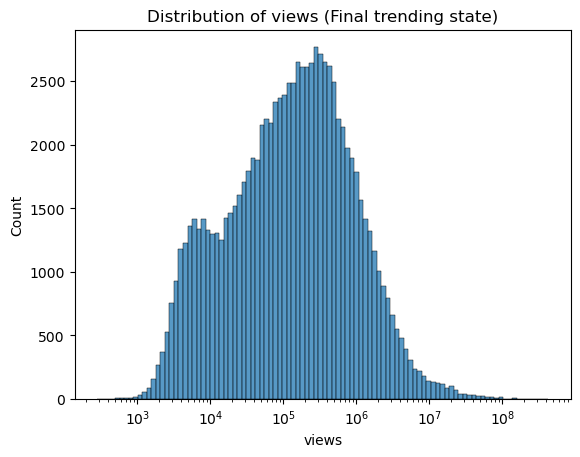

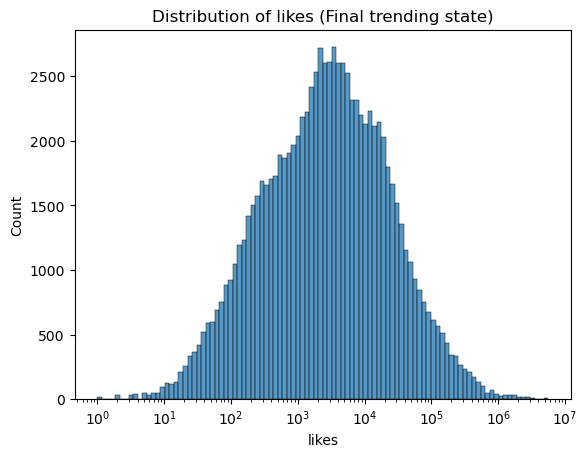

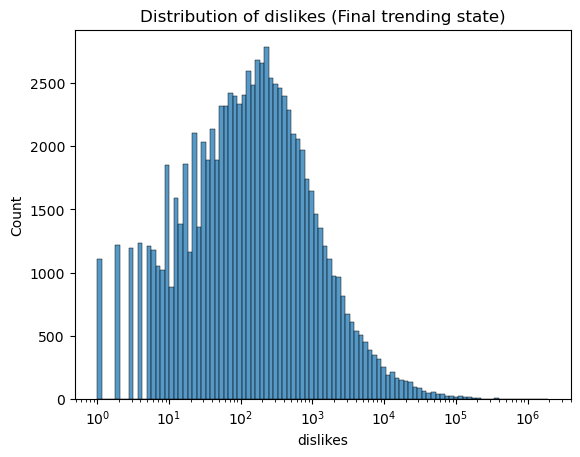

In [26]:
latest_df = df.sort_values('trending_date').groupby(['country', 'video_id'], as_index=False).last()

for col in ['views', 'likes', 'dislikes']:
    sns.histplot(latest_df[col], bins=100, log_scale=(True, False))
    plt.title(f'Distribution of {col} (Final trending state)')
    plt.show()

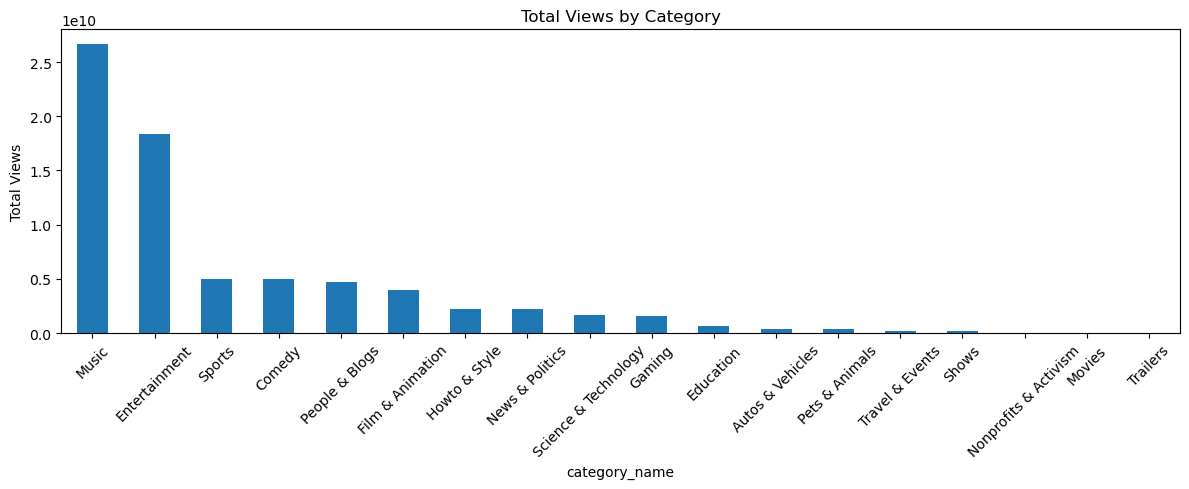

In [27]:
category_totals = latest_df.groupby('category_name')[['views', 'likes', 'dislikes']].sum().sort_values('views', ascending=False)
category_totals['views'].plot(kind='bar', figsize=(12, 5), title='Total Views by Category')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

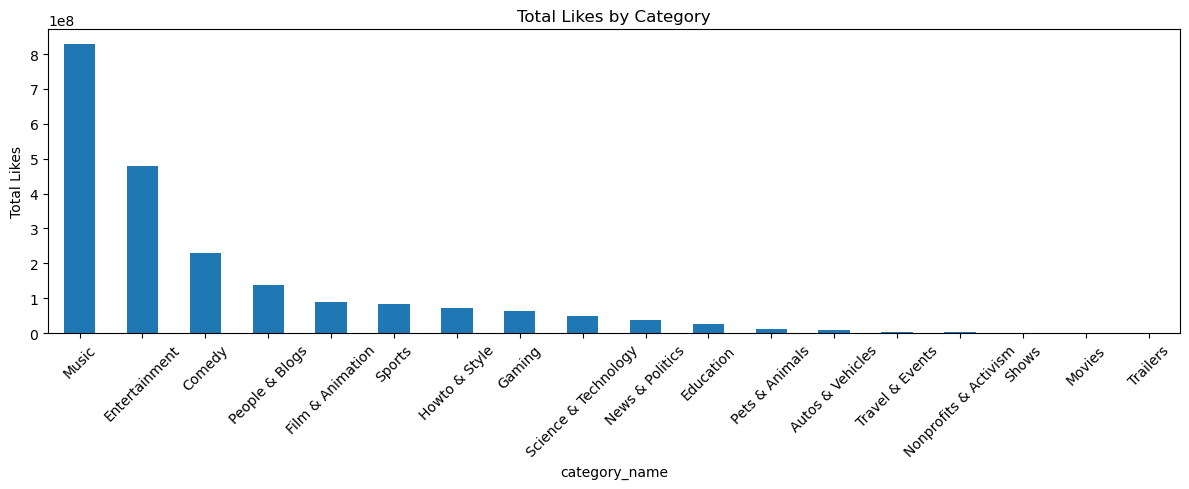

In [28]:
category_totals = latest_df.groupby('category_name')[['views', 'likes', 'dislikes']].sum().sort_values('likes', ascending=False)
category_totals['likes'].plot(kind='bar', figsize=(12, 5), title='Total Likes by Category')
plt.ylabel('Total Likes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

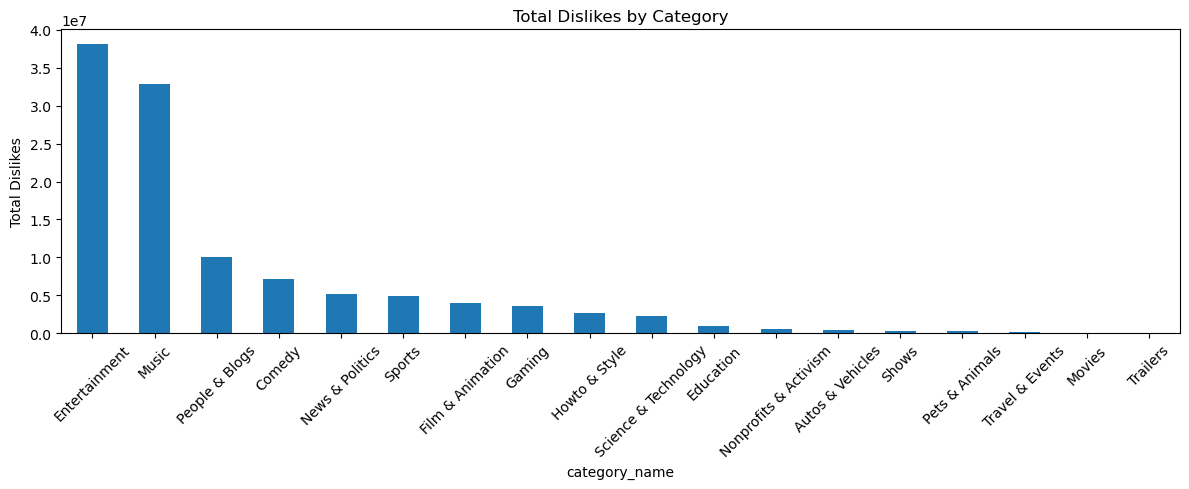

In [29]:
category_totals = latest_df.groupby('category_name')[['views', 'likes', 'dislikes']].sum().sort_values('dislikes', ascending=False)
category_totals['dislikes'].plot(kind='bar', figsize=(12, 5), title='Total Dislikes by Category')
plt.ylabel('Total Dislikes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

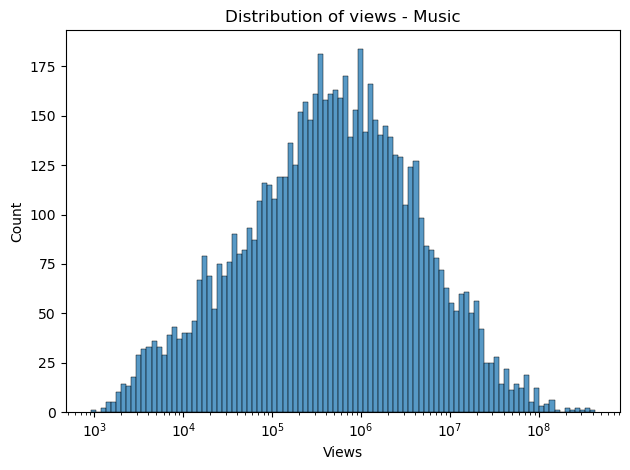

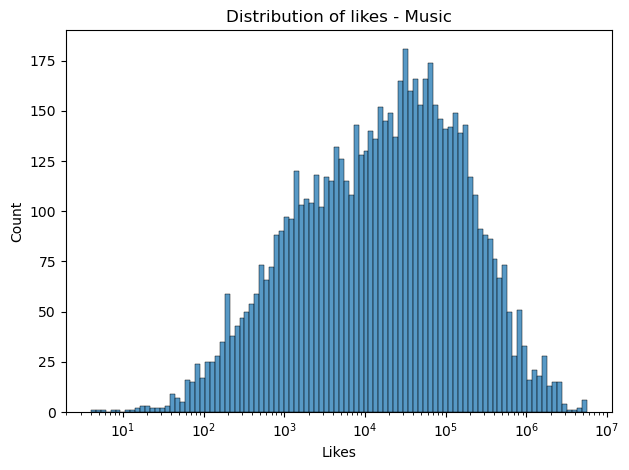

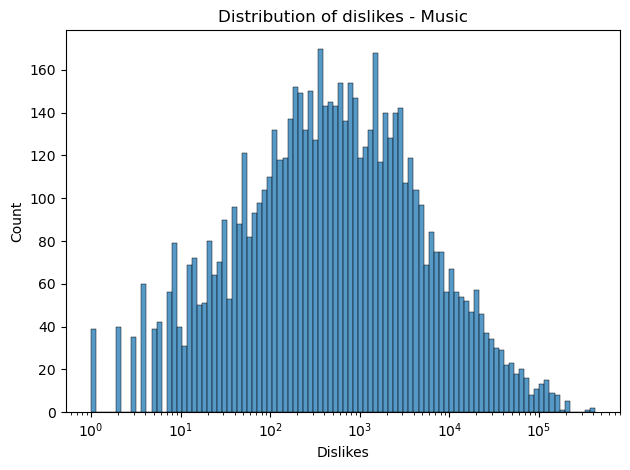

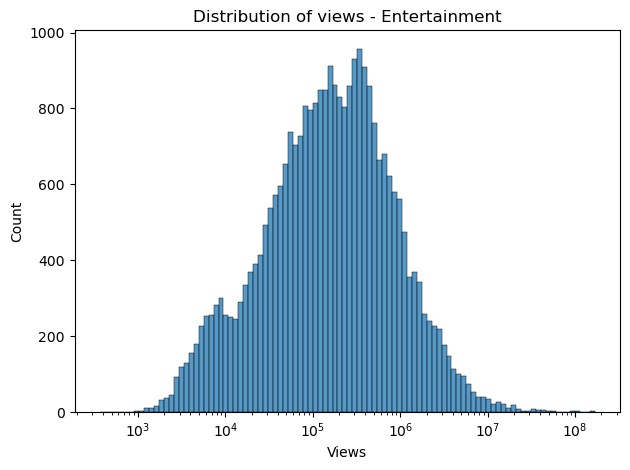

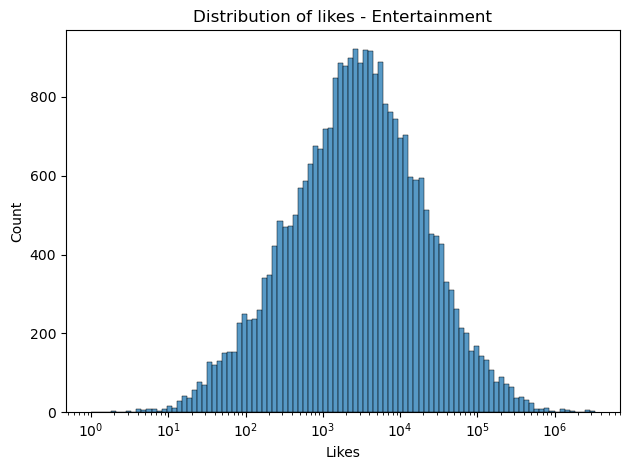

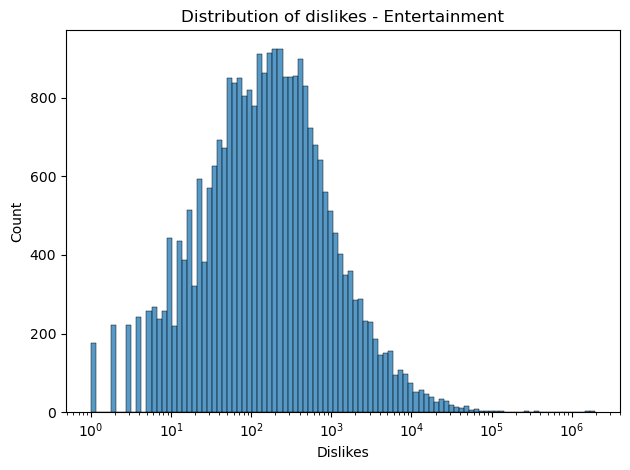

In [30]:
for category in ['Music', 'Entertainment']:
    category_data = latest_df[latest_df['category_name'] == category]
    for col in ['views', 'likes', 'dislikes']:
        sns.histplot(category_data[col], bins=100, log_scale=(True, False))
        plt.title(f'Distribution of {col} - {category}')
        plt.xlabel(col.capitalize())
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

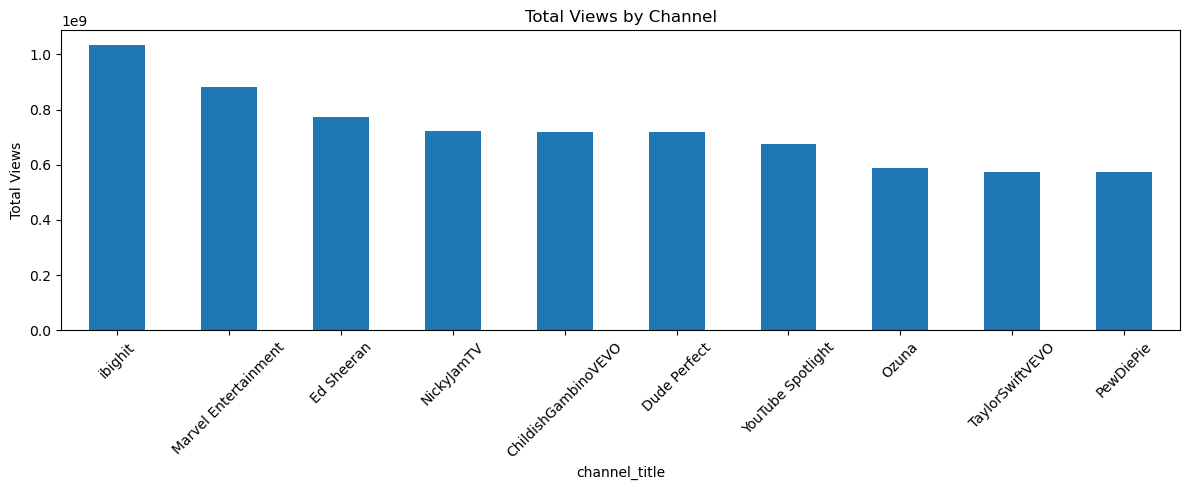

In [31]:
channels_totals = latest_df.groupby('channel_title')[['views', 'likes', 'dislikes']].sum().sort_values('views', ascending=False)
channels_totals.head(10)['views'].plot(kind='bar', figsize=(12, 5), title='Total Views by Channel')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

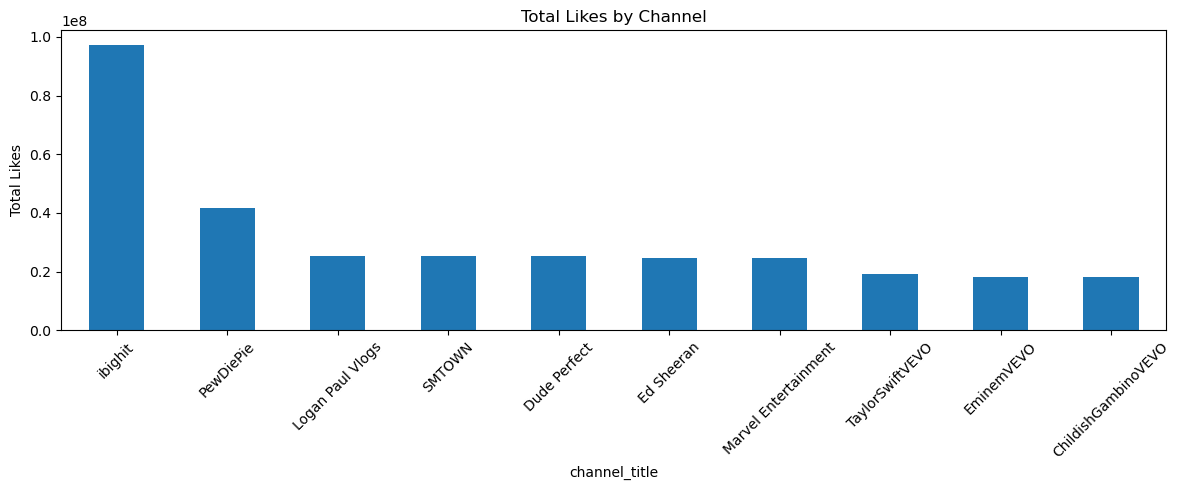

In [32]:
channels_totals = latest_df.groupby('channel_title')[['views', 'likes', 'dislikes']].sum().sort_values('likes', ascending=False)
channels_totals.head(10)['likes'].plot(kind='bar', figsize=(12, 5), title='Total Likes by Channel')
plt.ylabel('Total Likes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

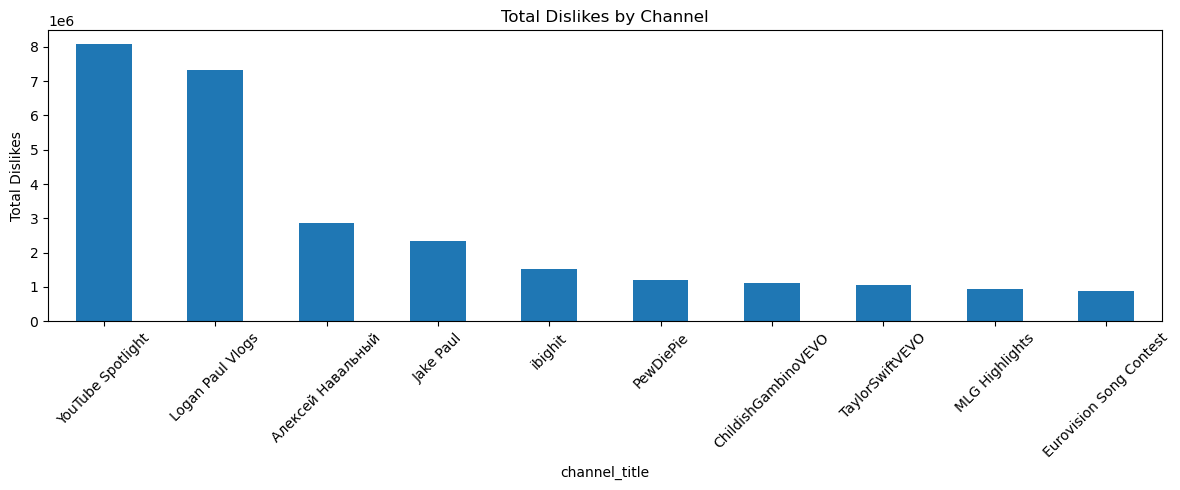

In [33]:
channels_totals = latest_df.groupby('channel_title')[['views', 'likes', 'dislikes']].sum().sort_values('dislikes', ascending=False)
channels_totals.head(10)['dislikes'].plot(kind='bar', figsize=(12, 5), title='Total Dislikes by Channel')
plt.ylabel('Total Dislikes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Impact of Upload Time and Seasonal Patterns

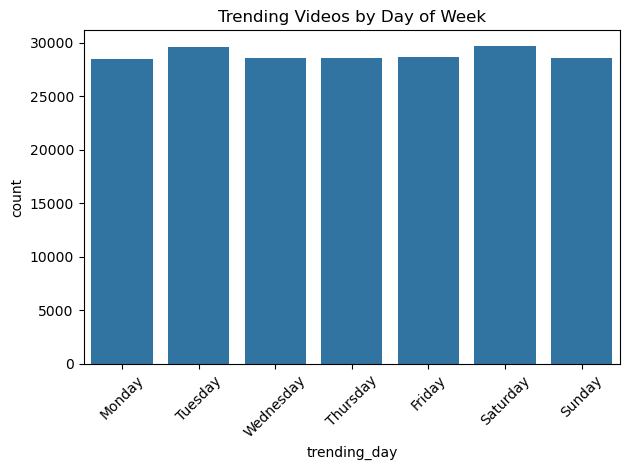

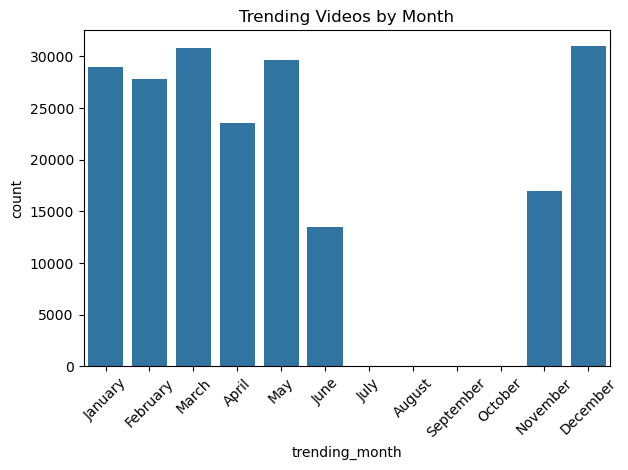

In [36]:
sns.countplot(data=df, x='trending_day', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Trending Videos by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


sns.countplot(data=df, x='trending_month', order=[
    'January','February','March','April','May','June','July','August','September','October','November','December'
])
plt.title('Trending Videos by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

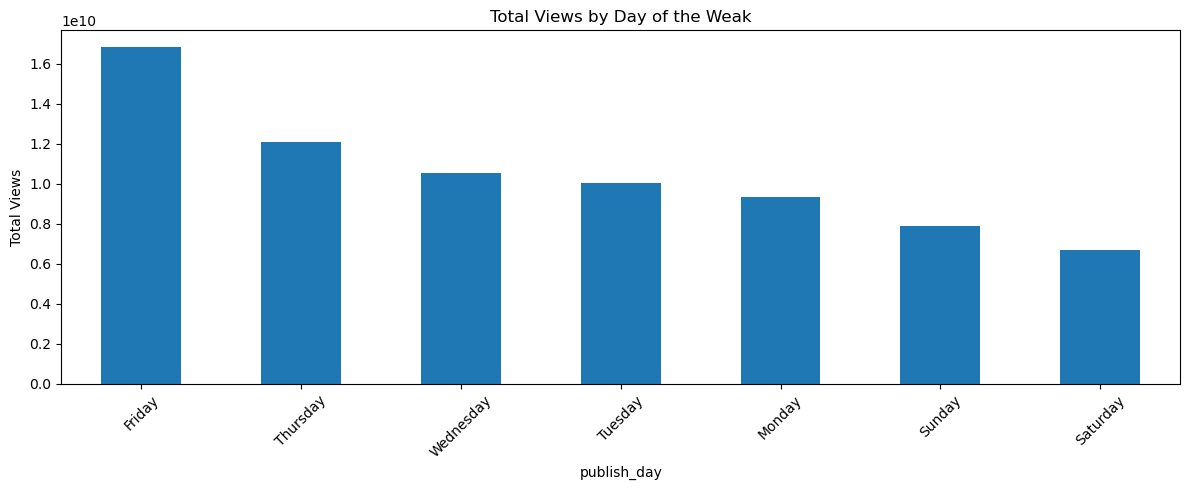

In [38]:
day_totals = latest_df.groupby('publish_day')[['views', 'likes', 'dislikes']].sum().sort_values('views', ascending=False)
day_totals['views'].plot(kind='bar', figsize=(12, 5), title='Total Views by Day of the Weak')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

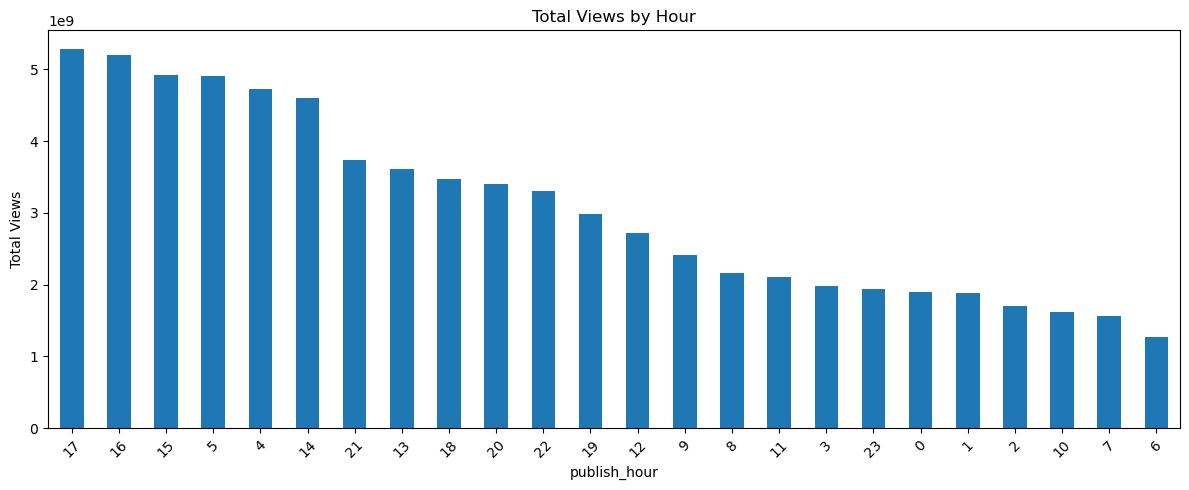

In [39]:
day_totals = latest_df.groupby('publish_hour')[['views', 'likes', 'dislikes']].sum().sort_values('views', ascending=False)
day_totals['views'].plot(kind='bar', figsize=(12, 5), title='Total Views by Hour')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Compare Controversial Videos with Universally Liked Ones

In [85]:
controversial = latest_df[latest_df['dislike_ratio'] > 0.5]
liked = latest_df[latest_df['dislike_ratio'] < 0.1]

In [42]:
metrics = ['views', 'comment_count']

print("Controversial videos (high dislike ratio):")
print(controversial[metrics].mean())

print("\nUniversally liked videos (low dislike ratio):")
print(liked[metrics].mean())

Controversial videos (high dislike ratio):
views            447268.062022
comment_count      4610.584537
dtype: float64

Universally liked videos (low dislike ratio):
views            842140.492790
comment_count      2893.486739
dtype: float64


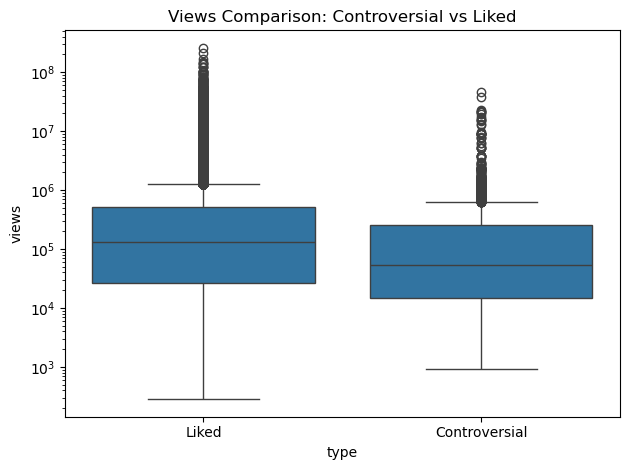

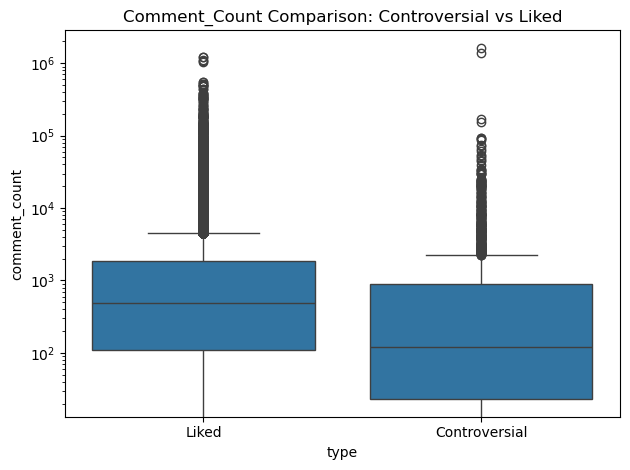

In [43]:
latest_df['type'] = 'Neutral'
latest_df.loc[latest_df['dislike_ratio'] > 0.4, 'type'] = 'Controversial'
latest_df.loc[latest_df['dislike_ratio'] < 0.05, 'type'] = 'Liked'

for metric in metrics:
    sns.boxplot(data=latest_df[latest_df['type'] != 'Neutral'], x='type', y=metric)
    plt.title(f'{metric.title()} Comparison: Controversial vs Liked')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()


### Influence of Tags in Engagement

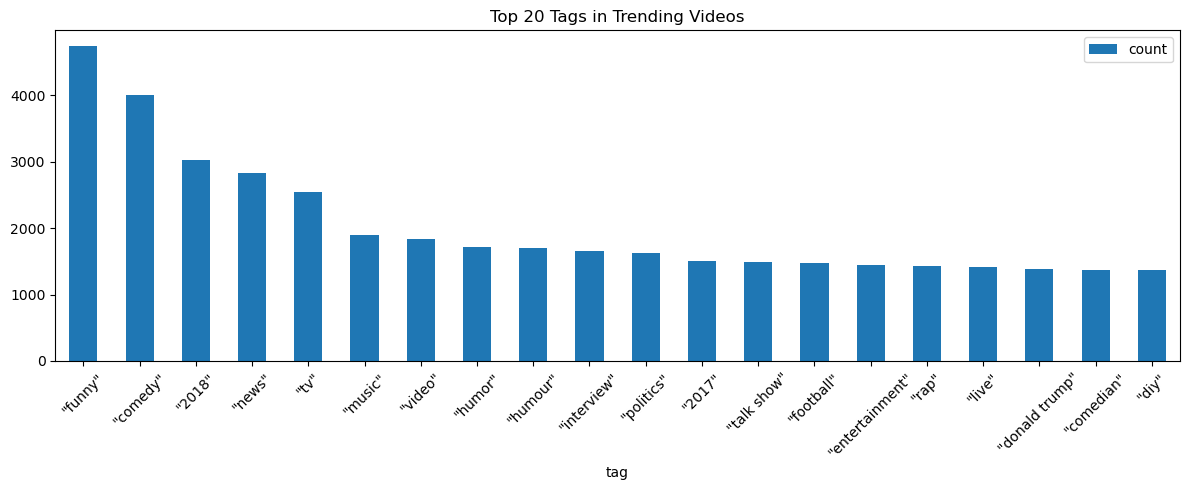

In [48]:
from collections import Counter
all_tags = latest_df['tags'].dropna().str.lower().str.split('|')
tag_counter = Counter(tag for tags in all_tags for tag in tags if tag != '[none]')

top_tags_df = pd.DataFrame(tag_counter.most_common(20), columns=['tag', 'count'])
top_tags_df.plot.bar(x='tag', y='count', figsize=(12,5), title='Top 20 Tags in Trending Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


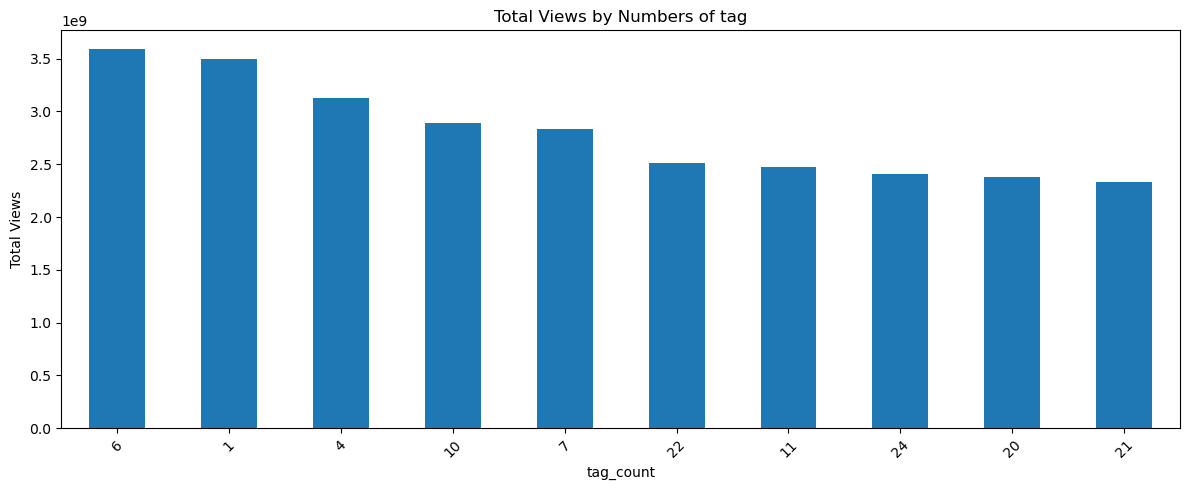

In [50]:
latest_df['tag_count'] = latest_df['tags'].apply(lambda x: 0 if pd.isna(x) else len(x.split('|')))

tag_totals = latest_df.groupby('tag_count')[['views', 'likes', 'dislikes']].sum().sort_values('views', ascending=False)
tag_totals['views'].head(10).plot(kind='bar', figsize=(12, 5), title='Total Views by Numbers of tag')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
top_tags = [tag for tag, _ in tag_counter.most_common(10)]

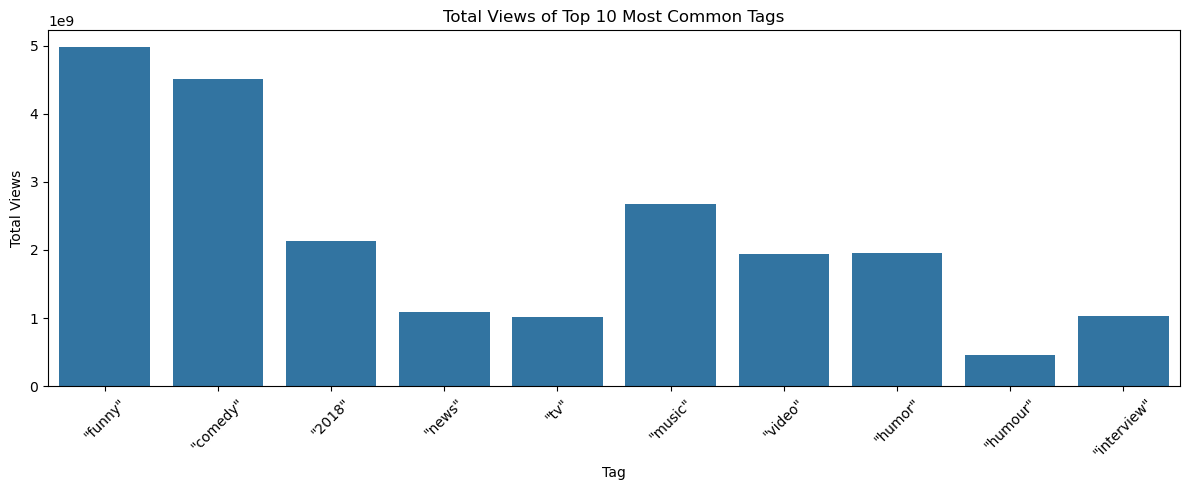

In [74]:
tag_views = {}

for tag in top_tags:
    mask = latest_df['tags'].str.lower().str.contains(f'{tag}', na=False)
    tag_views[tag] = latest_df.loc[mask, 'views'].sum()


plt.figure(figsize=(12, 5))
sns.barplot(x=list(tag_views.keys()), y=list(tag_views.values()))
plt.title("Total Views of Top 10 Most Common Tags")
plt.ylabel("Total Views")
plt.xlabel("Tag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

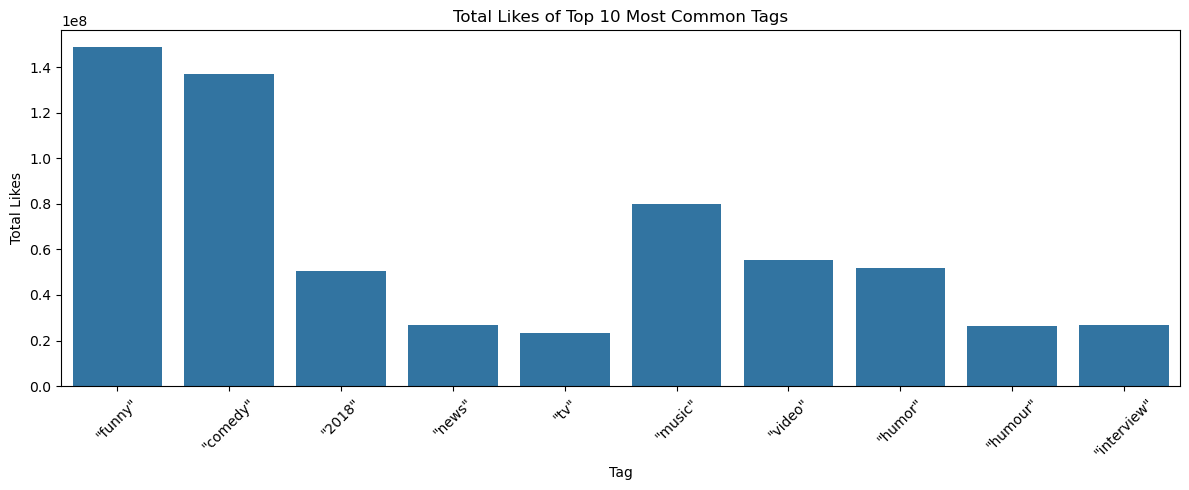

In [76]:
tag_likes = {}

for tag in top_tags:
    mask = latest_df['tags'].str.lower().str.contains(f'{tag}', na=False)
    tag_likes[tag] = latest_df.loc[mask, 'likes'].sum()


plt.figure(figsize=(12, 5))
sns.barplot(x=list(tag_likes.keys()), y=list(tag_likes.values()))
plt.title("Total Likes of Top 10 Most Common Tags")
plt.ylabel("Total Likes")
plt.xlabel("Tag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
latest_df['title_length'] = latest_df['title'].str.len()
mean_title_len = latest_df['title_length'].mean()

latest_df['title_group'] = latest_df['title_length'].apply(lambda x: 'Short' if x < mean_title_len else 'Long')
group_stats = latest_df.groupby('title_group')[['views', 'likes']].mean()
print(group_stats)

                     views         likes
title_group                             
Long         618813.292857  14261.531401
Short        912721.326368  29767.805211


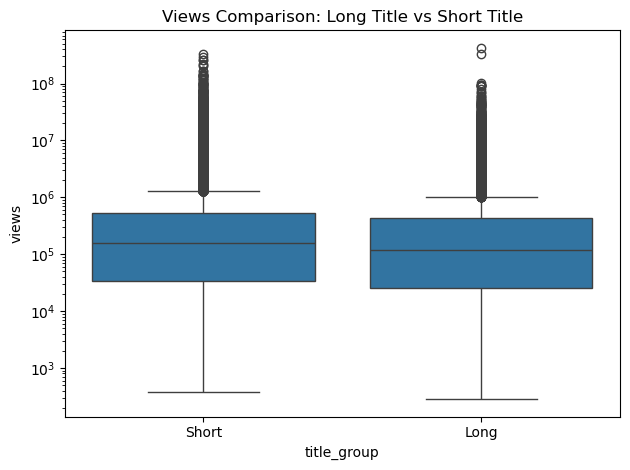

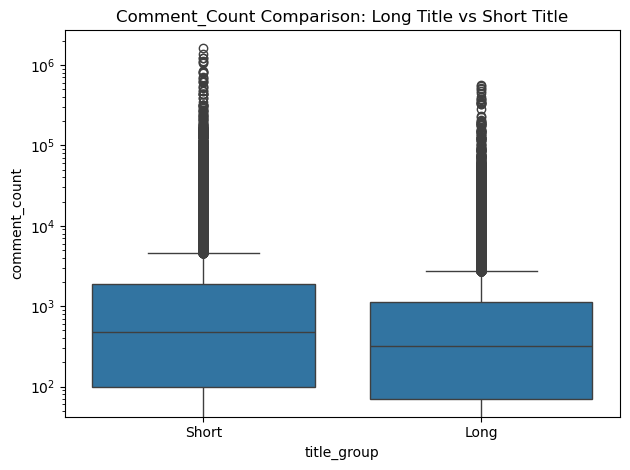

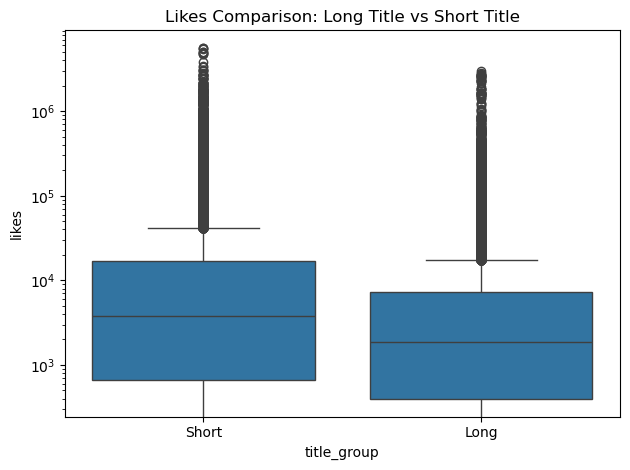

In [92]:
metrics = ['views', 'comment_count', 'likes']

for metric in metrics:
    sns.boxplot(data=latest_df, x='title_group', y=metric)
    plt.title(f'{metric.title()} Comparison: Long Title vs Short Title')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

### Title Sentiment Analysis

In [94]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

latest_df['sentiment'] = latest_df['title'].apply(get_sentiment)

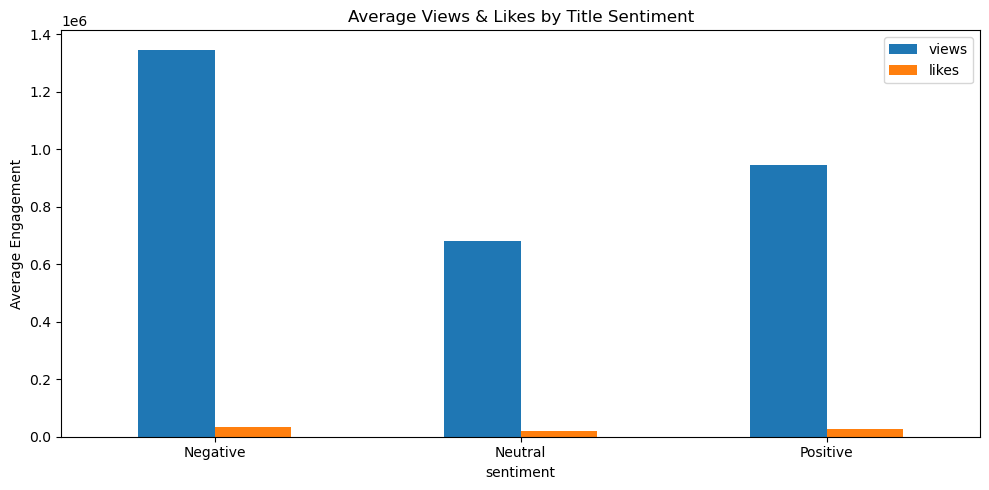

In [97]:
sentiment_stats = latest_df.groupby('sentiment')[['views', 'likes', 'dislikes', 'comment_count']].mean()
sentiment_stats[['views', 'likes']].plot(kind='bar', figsize=(10, 5), title='Average Views & Likes by Title Sentiment')
plt.ylabel('Average Engagement')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

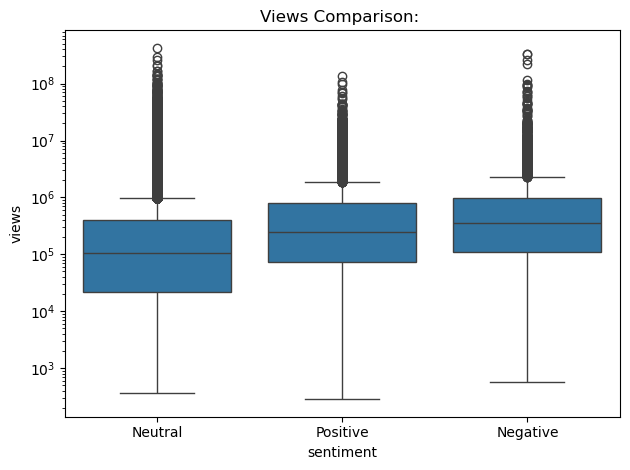

In [99]:
sns.boxplot(data=latest_df, x='sentiment', y='views')
plt.title(f'{'views'.title()} Comparison: ')
plt.yscale('log')
plt.tight_layout()
plt.show()

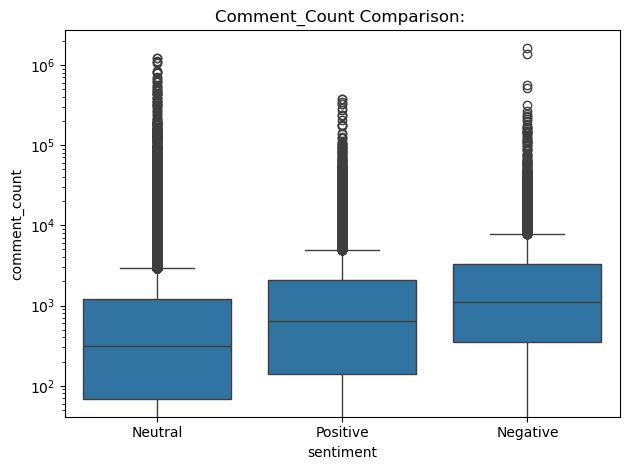

In [100]:
sns.boxplot(data=latest_df, x='sentiment', y='comment_count')
plt.title(f'{'comment_count'.title()} Comparison: ')
plt.yscale('log')
plt.tight_layout()
plt.show()

1. there is 79408 unique video but some same videos have different names we try to normalize them but there is still some videos with equal id and different name maybe because their name is translate in other languages throgh different countries.
2. the data is collected throgh 205 days
3. 6942 videos have no description
4. 35 videos use the same thumbnail link that guid us to find that there is some deleted videos removing all deleted videos from the data we have 79384 video_id, 79494 unique title and 79389 thumbnail_link that and we find that 5 video_id have 2 thumbnail_link and we see an exmaple of them
5. at last we set title of each rows with equal video_id to the most frequent one and that makes to see that title unique value now is less than id is that make more sence becuase different videos might same name
6. we use json file for each country to map category id to the category name for each row of the dataset
7. converting all data to datetime dtype and extract from them public hour and day of the week
8. costruct and feature engeereing to acheave dislike ratio and title lenth and title sentiment that are used for analisys key question
9. constructing the last day od trending vieos in each county to get the most cumulative reward and then use hisplot to see the distribution for them and see that for likes and view it is almost normal but for dislikes it is skewd to the right
10. sum up all metrics in each category using the new dataset we construct and plot them against each category we see that music and entetainment are at top in all three metrics
11. then we see the distribution of metrics in two most trended categories and see that they are almost normal expet dislikes for entertainment and likes of musics that skwed to the right and left respectedly.
12. then we use bar plot for channels metrics and see that ibigight and marvel entertainment have most vies and ibigight and pwedepie have most likes and youtube spotlight and logan paul vlogs have most dislikes
13. we plot the numbers od video that become tren in each day of week and month and we realize that it is equal to each day of weak and dstribute (همگن) but for month the four july, august, september, october has no trend video june and novomber are less than other and others month are equal.
14. we use the same bar plot that we use for categories and we realize that the videos that publish at friday at 17 hour are most viewed among the others
15. we compare the views and comment count for controvesial and liked videos and use box plots to visualize them and we see that the liked ones are more engage that controvesials that the mean for both of these are more than other groups
16. extract all tags from the tag columns and then use counter to find top 20 most common tags and plot them to see and compare them the top 4 common are funny, comedy, 2018
17. we use bar plot to see the pattern of numbers of tag and views but there is no pattern and the numbers that have most views are random order
18. we use bar plot and see that the videos that contains tag funny comedy and music have most views and likes
19. we grouped the videos by the titles len and make two group long and short and use box plots to compare the likes, views and comment_count for them and views and comment are almost equal and likes for shot titles are a little more that other group
20. extract sentiment of titles using textblob we find that videos with negative sentiment have more views and comments and with natural heve least views and comments
21. 